#Retail Demand Forecasting
**Business Problem:** Inaccurate demand forecasts cost retailers millions annually through overstock write-offs and lost sales from empty shelves. This project builds a production-grade forecasting pipeline that predicts daily sales across 54 stores and 33 product families — with explainability and uncertainty quantification built in.

###Goal
Load the 4 raw CSVs, merge them into a single clean panel dataframe, handle missing values, and save as parquet for downstream scripts.

[![Dataset](https://img.shields.io/badge/Dataset-Kaggle%20Store%20Sales-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)
[![Python](https://img.shields.io/badge/Python-3.10-3776AB?logo=python&logoColor=white)](https://www.python.org/)
[![LightGBM](https://img.shields.io/badge/Model-LightGBM-9ACD32?logo=lightgbm&logoColor=white)](https://lightgbm.readthedocs.io/)
[![MLflow](https://img.shields.io/badge/Tracking-MLflow-0194E2?logo=mlflow&logoColor=white)](https://mlflow.org/)
[![SHAP](https://img.shields.io/badge/Explainability-SHAP-FF6B6B)](https://shap.readthedocs.io/)
[![Streamlit](https://img.shields.io/badge/Deployment-Streamlit-FF4B4B?logo=streamlit&logoColor=white)](https://streamlit.io/)

### 1. Mount Drive & Install Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pyarrow fastparquet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.0 MB/s eta 0:00:00


## 2. Imports & Config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Path where you extracted the zip
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/'

print('Libraries loaded successfully')

Libraries loaded successfully


In [4]:
# import zipfile

# zip_path = "/content/drive/MyDrive/Colab Notebooks/Demand forecasting project/store-sales-time-series-forecasting.zip"
# extract_path = "/content/drive/MyDrive/Colab Notebooks/Demand forecasting project/"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

## 3. Load Raw CSVs
We load 4 files:
- `train.csv` — daily sales per store + product family
- `stores.csv` — store metadata (city, state, type, cluster)
- `oil.csv` — daily oil price (Ecuador is oil-dependent economy — strong demand signal)
- `holidays_events.csv` — national/regional/local holidays and events

In [5]:
train = pd.read_csv(DATA_PATH + 'train.csv', parse_dates=['date'])
stores = pd.read_csv(DATA_PATH + 'stores.csv')
oil = pd.read_csv(DATA_PATH + 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(DATA_PATH + 'holidays_events.csv', parse_dates=['date'])

print(f'train shape      : {train.shape}')
print(f'stores shape     : {stores.shape}')
print(f'oil shape        : {oil.shape}')
print(f'holidays shape   : {holidays.shape}')

train shape      : (3000888, 6)
stores shape     : (54, 5)
oil shape        : (1218, 2)
holidays shape   : (350, 6)


## 4. Explore Raw Train Data

In [7]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(train.head())
print('\nDate range:', train['date'].min(), 'to', train['date'].max())
print('Stores    :', train['store_nbr'].nunique())
print('Families  :', train['family'].nunique())
print('\nSales stats:')
print(train['sales'].describe())

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE   0.00            0
1   1 2013-01-01          1   BABY CARE   0.00            0
2   2 2013-01-01          1      BEAUTY   0.00            0
3   3 2013-01-01          1   BEVERAGES   0.00            0
4   4 2013-01-01          1       BOOKS   0.00            0

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Stores    : 54
Families  : 33

Sales stats:
count   3,000,888.00
mean          357.78
std         1,102.00
min             0.00
25%             0.00
50%            11.00
75%           195.85
max       124,717.00
Name: sales, dtype: float64


In [8]:
# Check for negative sales — these are data errors, not returns
neg = train[train['sales'] < 0]
print(f'Negative sales rows: {len(neg)}')
if len(neg) > 0:
    print(neg.head())

Negative sales rows: 0


## 5. Clean Train Data

In [9]:
# Check duplicates
dupes = train.duplicated(subset=['date', 'store_nbr', 'family']).sum()
print(f'Duplicate rows: {dupes}')  # should be 0

# Drop id column — not needed for modelling
train = train.drop(columns=['id'])

print('Train cleaned. Shape:', train.shape)

Duplicate rows: 0
Train cleaned. Shape: (3000888, 5)


## 6. Process Oil Prices

In [10]:
print('Oil missing values before:', oil['dcoilwtico'].isna().sum())

# Sort and forward-fill
oil = oil.sort_values('date').reset_index(drop=True)
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

print('Oil missing values after :', oil['dcoilwtico'].isna().sum())
print(oil.head())

Oil missing values before: 43
Oil missing values after : 0
        date  dcoilwtico
0 2013-01-01       93.14
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20


## 7. Process Holidays

In [11]:
# We only want national holidays that affect all stores equally.
print('Holiday types:')
print(holidays['locale'].value_counts())
print('\nHoliday types (event type):')
print(holidays['type'].value_counts())

Holiday types:
locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

Holiday types (event type):
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64


In [12]:
# Create national holiday flag — 1 if that date is a national holiday
national_holidays = holidays[
    (holidays['locale'] == 'National') &
    (holidays['transferred'] == False)
][['date']].drop_duplicates()

national_holidays['is_holiday'] = 1

print(f'National holiday dates: {len(national_holidays)}')

National holiday dates: 160


## 8. Merge Everything into Panel DataFrame

In [13]:
# Merge train with store metadata
panel = train.merge(stores, on='store_nbr', how='left')
print('After stores merge:', panel.shape)

# Merge with oil prices
panel = panel.merge(oil, on='date', how='left')
print('After oil merge   :', panel.shape)

# Merge with national holidays
panel = panel.merge(national_holidays, on='date', how='left')
panel['is_holiday'] = panel['is_holiday'].fillna(0).astype(int)
print('After holiday merge:', panel.shape)

print('\nPanel columns:', panel.columns.tolist())

After stores merge: (3000888, 9)
After oil merge   : (3000888, 10)
After holiday merge: (3000888, 11)

Panel columns: ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_holiday']


## 9. Final Checks

In [14]:
print('Null counts:')
print(panel.isnull().sum())
print('\nDtypes:')
print(panel.dtypes)

Null counts:
date                0
store_nbr           0
family              0
sales               0
onpromotion         0
city                0
state               0
type                0
cluster             0
dcoilwtico     857142
is_holiday          0
dtype: int64

Dtypes:
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
city                   object
state                  object
type                   object
cluster                 int64
dcoilwtico            float64
is_holiday              int64
dtype: object


In [15]:
# sanity check — total sales should be positive
print(f'Total sales       : {panel["sales"].sum():,.0f}')
print(f'Zero sales rows   : {(panel["sales"] == 0).sum():,} ({(panel["sales"] == 0).mean()*100:.1f}%)')
print(f'Date range        : {panel["date"].min()} to {panel["date"].max()}')
print(f'Unique stores     : {panel["store_nbr"].nunique()}')
print(f'Unique families   : {panel["family"].nunique()}')

Total sales       : 1,073,644,952
Zero sales rows   : 939,130 (31.3%)
Date range        : 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Unique stores     : 54
Unique families   : 33


## 10. Sales Trend Plot

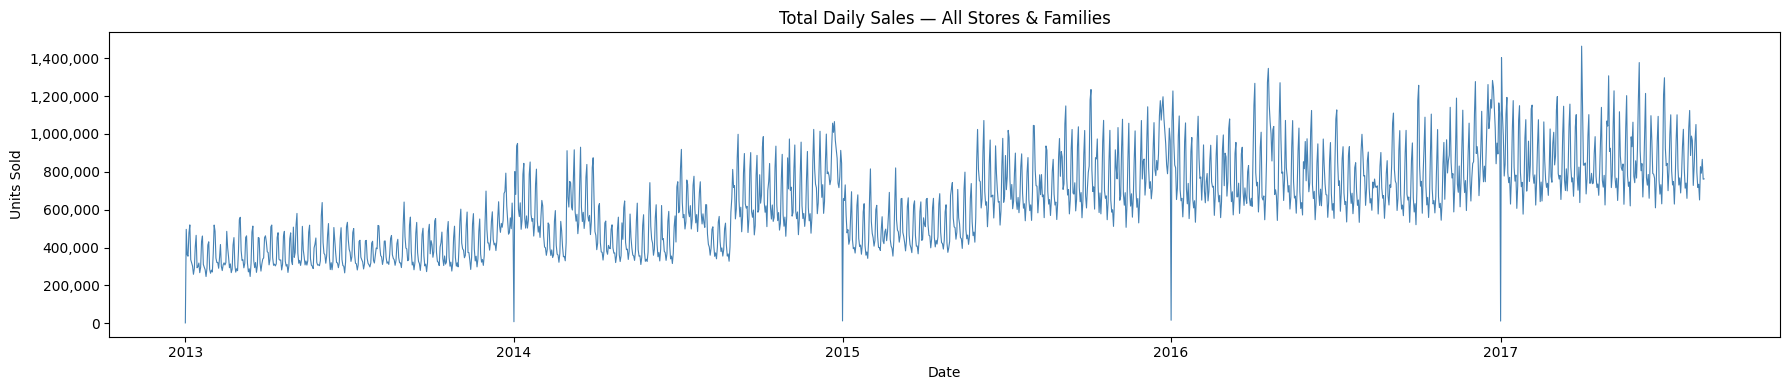

Plot saved.


In [20]:
import matplotlib.ticker as ticker
daily_sales = panel.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(18, 4))
plt.plot(daily_sales['date'], daily_sales['sales'], linewidth=0.8, color='steelblue')
plt.title('Total Daily Sales — All Stores & Families')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'daily_sales_trend.png', dpi=120)
plt.show()
print('Plot saved.')

## 11. Save Clean Panel
Save as parquet — ~10x faster to load than CSV for downstream scripts.

In [22]:
output_path = DATA_PATH + 'panel_clean.parquet'
panel.to_parquet(output_path, index=False)

# Verify by reloading
check = pd.read_parquet(output_path)
print(f'Saved and verified: {check.shape}')
print(f'File location: {output_path}')

Saved and verified: (3000888, 11)
File location: /content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/panel_clean.parquet
